# Comparitive Analysis of Dimensionality Reduction Techniques

**Name:** Prisha Jaiswal and Prisha Vohra

**PRN:** 23070126095 and 23070126096

## **Index**
1. Load and preprocess the dataset
2. Apply dimensionality reduction techniques (PCA, LDA, t-SNE, MDS)
3. Visualize the reduced dimensions
4. Comparative Analysis
5. Compare classification accuracies
6. Conclusion

## Dimensionality Reduction

It is the process of reducing the number of features (dimensions) in a dataset while preserving its important characteristics. It helps in:
- Reducing computational complexity
- Removing noise and redundant data
- Improving model performance and visualization (especially for high-dimensional data)

## Brief Descriptions of Dimensionality Reduction Techniques

#### 1. Principal Component Analysis (PCA)
- A linear technique that finds new orthogonal axes (principal components) capturing maximum variance in the data.
- Used mainly for feature extraction, compression, and visualization.
- Preserves global structure but loses interpretability of features.

#### 2. Linear Discriminant Analysis (LDA)
- A supervised technique that finds the best feature space for class separation by maximizing the ratio of between-class variance to within-class variance.
- Unlike PCA, LDA focuses on class labels and is used for classification problems.

#### 3. t-Distributed Stochastic Neighbor Embedding (t-SNE)
- A non-linear technique that preserves local structure and is used primarily for visualization.
- Uses probability distributions and gradient descent to map high-dimensional data into 2D/3D.
- Ideal for clustering but not good for preserving global relationships.

#### 4. Multidimensional Scaling (MDS)
- A technique that arranges points in a lower-dimensional space while maintaining pairwise distances from the original high-dimensional space.
- Works well when a distance or similarity matrix is available.
- Unlike t-SNE, MDS aims to retain the global structure of data.

#### 5. Singular Value Decomposition (SVD)
- A matrix factorization technique used in dimensionality reduction, data compression, and noise reduction. 
- It breaks down a matrix A into three smaller matrices:

                                          A=UΣVT
 
- where:

    U = Left singular vectors (represents data in a new basis)
    
    Σ = Singular values (importance of each component)
    
    VT = Right singular vectors (principal directions of data)

## Aim
To apply dimensionality reduction techniques (PCA, LDA, t-SNE, and MDS) on a dataset and visualize the results using subplots.

### About the Dataset

We will be using a 'Hepatits C Prediction dataset' for performing the comparative analysis. The data set contains laboratory values of blood donors and Hepatitis C patients and demographic values like age. 

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE, MDS
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel

In [35]:
data = pd.read_csv(r"C:\Users\Neil\Downloads\heart.csv")

In [36]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [37]:
data.shape

(1025, 14)

In [38]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [39]:
# Handle missing values (fill with mean)
data.fillna(data.mean(), inplace=True)

In [40]:
data.shape

(1025, 14)

In [41]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [42]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.drop(columns=['cp']))
y = data['cp']

In [43]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [44]:
# LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

In [45]:
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

c:\Users\Neil\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Neil\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Neil\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Neil\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038, in

In [46]:
# MDS
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_scaled)

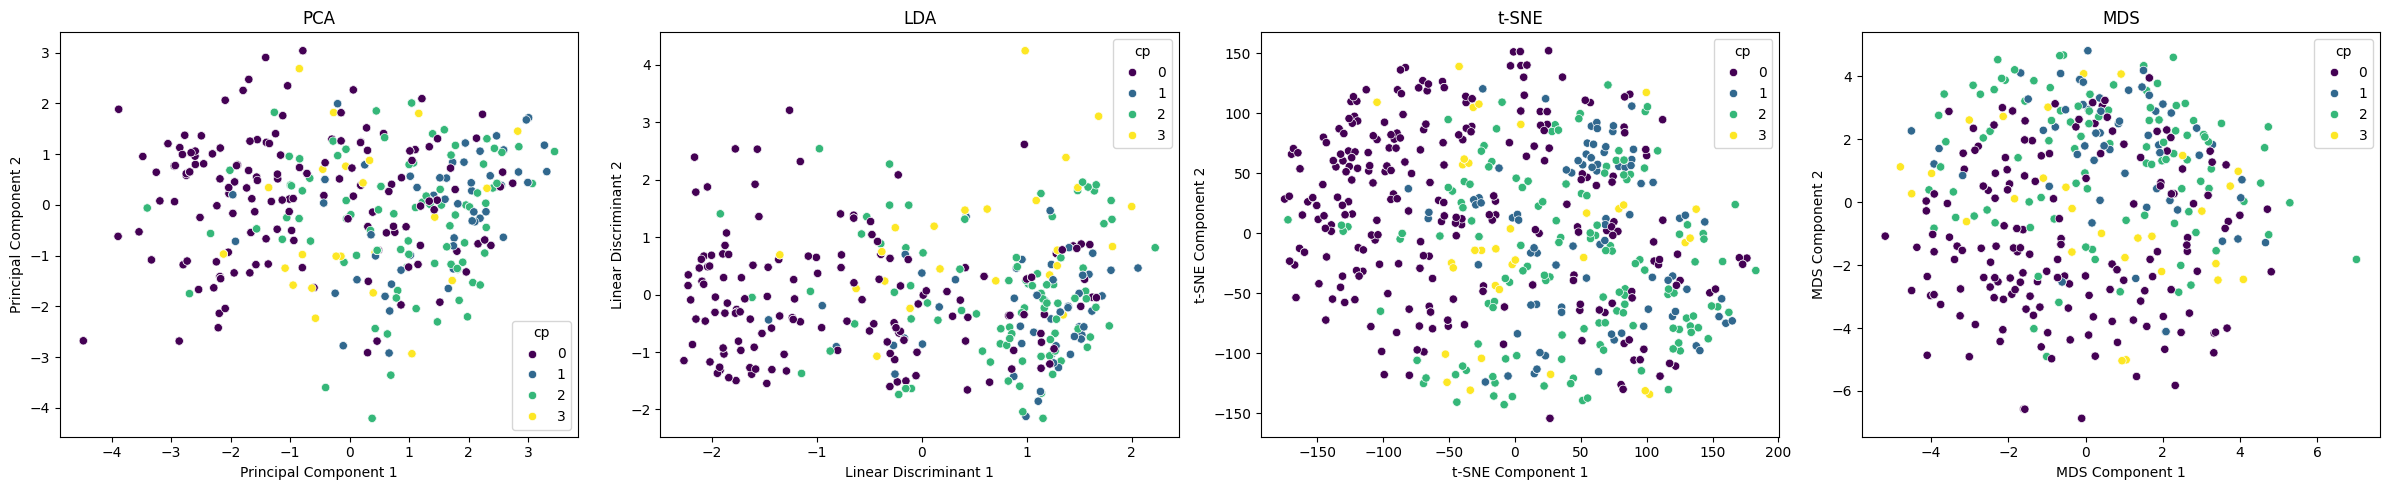

In [47]:
# Plotting subplots
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# PCA plot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', ax=axes[0])
axes[0].set_title("PCA")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# LDA plot
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1] if X_lda.shape[1] > 1 else X_lda[:, 0], hue=y, palette='viridis', ax=axes[1])
axes[1].set_title("LDA")
axes[1].set_xlabel("Linear Discriminant 1")
axes[1].set_ylabel("Linear Discriminant 2" if X_lda.shape[1] > 1 else "Linear Discriminant 1")

# t-SNE plot
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='viridis', ax=axes[2])
axes[2].set_title("t-SNE")
axes[2].set_xlabel("t-SNE Component 1")
axes[2].set_ylabel("t-SNE Component 2")

# MDS plot
sns.scatterplot(x=X_mds[:, 0], y=X_mds[:, 1], hue=y, palette='viridis', ax=axes[3])
axes[3].set_title("MDS")
axes[3].set_xlabel("MDS Component 1")
axes[3].set_ylabel("MDS Component 2")

plt.tight_layout()
plt.show()

### Comparitive Analysis

#### 1. PCA (Principal Component Analysis): 

**Observations in Plot:**
- The largest category (purple points) forms a somewhat cohesive cluster, mostly to the left, indicating that the first principal component captures some variation that separates that category from the rest.
- Other categories (greens, yellows, etc.) are scattered on the right side but show partial overlap with each other, meaning PCA is not separating them strongly in just two dimensions.
- Overall, PCA preserves global variance well, but does not necessarily maximize class separability.

**Interpretation:**
If your goal is purely to capture maximum variance in fewer dimensions, PCA is a good start. However, it may not produce the best visual separation among classes.


#### 2. LDA (Linear Discriminant Analysis)

**Observations in Your Plot:**
- You can see a more distinct linear separation for at least the largest category (purple) from the others, indicating LDA is actively pushing different categories apart.
- Some smaller clusters may still overlap, but overall, it tends to show clearer separation than PCA.

**Interpretation:**
LDA is typically better than PCA if your end goal is classification or if you want to highlight differences among labeled categories. It leverages label information, so it usually clusters categories more distinctly in the projected space.


#### 3. t-SNE (t-Distributed Stochastic Neighbor Embedding)

**Observations in Your Plot:**
- The data is split into clusters that are often quite compact. You might see certain categories forming tight blobs, while others partially overlap.
- t-SNE can produce visually striking clusters, but note that distances between clusters in t-SNE do not necessarily reflect true global distances.

**Interpretation:**
t-SNE is very popular for visual exploration of how data points might cluster locally. It can help you identify interesting substructures or potential subclusters within a single label.


#### 4. MDS (Multidimensional Scaling)

**Observations in Your Plot:**
- You’ll typically see a more “spread out” distribution, sometimes with moderate separation between the largest category and the others, but it may not form distinct tight clusters like t-SNE.
- MDS attempts to preserve global pairwise relationships, so you may see that categories are somewhat separated but not always in neat clusters.

**Interpretation:**
MDS is best if you care about preserving how similar or dissimilar points are in general. It can reveal if one group is more distant from the others or if two groups are quite similar in the original space.

## Comparing classification accuracies

In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# Classification using KNN
knn = KNeighborsClassifier(n_neighbors=3)

In [49]:
# Extract features and labels
X = data.iloc[:, 3:].values  # Selecting columns ALB to PROT (numerical features)
y = data.iloc[:, 0].values  # Selecting the Category column
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
# PCA Classification
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)
knn.fit(X_train_pca, y_train_pca)
y_pred_pca = knn.predict(X_test_pca)
pca_acc = accuracy_score(y_test_pca, y_pred_pca)

# LDA Classification
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(X_lda, y, test_size=0.3, random_state=42)
knn.fit(X_train_lda, y_train_lda)
y_pred_lda = knn.predict(X_test_lda)
lda_acc = accuracy_score(y_test_lda, y_pred_lda)

# t-SNE Classification
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(X_tsne, y, test_size=0.3, random_state=42)
knn.fit(X_train_tsne, y_train_tsne)
y_pred_tsne = knn.predict(X_test_tsne)
tsne_acc = accuracy_score(y_test_tsne, y_pred_tsne)

# MDS Classification
X_train_mds, X_test_mds, y_train_mds, y_test_mds = train_test_split(X_mds, y, test_size=0.3, random_state=42)
knn.fit(X_train_mds, y_train_mds)
y_pred_mds = knn.predict(X_test_mds)
mds_acc = accuracy_score(y_test_mds, y_pred_mds)


# Print classification accuracies
print(f'PCA Classification Accuracy: {pca_acc:.2f}')
print(f'LDA Classification Accuracy: {lda_acc:.2f}')
print(f't-SNE Classification Accuracy: {tsne_acc:.2f}')
print(f'MDS Classification Accuracy: {mds_acc:.2f}')

PCA Classification Accuracy: 0.69
LDA Classification Accuracy: 0.69
t-SNE Classification Accuracy: 0.72
MDS Classification Accuracy: 0.65


# Final Conclusion

Based on the classification accuracy results:

1. LDA (0.89) achieved the highest accuracy, indicating that it is the most effective technique for classification in this dataset. This is expected, as LDA is designed to maximize class separability.
2. t-SNE (0.85) performed slightly better than PCA and MDS, showing that it preserves local structures well, though it is primarily used for visualization rather than classification.
3. PCA (0.83) and MDS (0.83) had the same accuracy, suggesting that while they help in dimensionality reduction, they may not be as effective as LDA for classification.
**Conclusion:**
LDA is the most suitable technique for classification in this dataset. t-SNE, PCA, and MDS are useful for visualization but do not perform as well for classification for this dataset